In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [12]:
fileName = "LA_AQS_2023.csv"

df = pd.read_csv(fileName)
df["Date (Local)"] = pd.to_datetime(df["Date (Local)"])

In [14]:
df_NO2 = df[(df['Parameter Name']=='Nitrogen dioxide (NO2)') & (df['Duration Description']=='1 HOUR')].copy()
df_NO2 = df_NO2.groupby("Date (Local)", as_index=False)["Arithmetic Mean"].mean()
df_NO2["NO2"] = df_NO2["Arithmetic Mean"]

df_O3 = df[(df['Parameter Name']=='Ozone') & (df['Duration Description']=='1 HOUR')].copy()
df_O3["O3"] = df_O3["Arithmetic Mean"]*1000

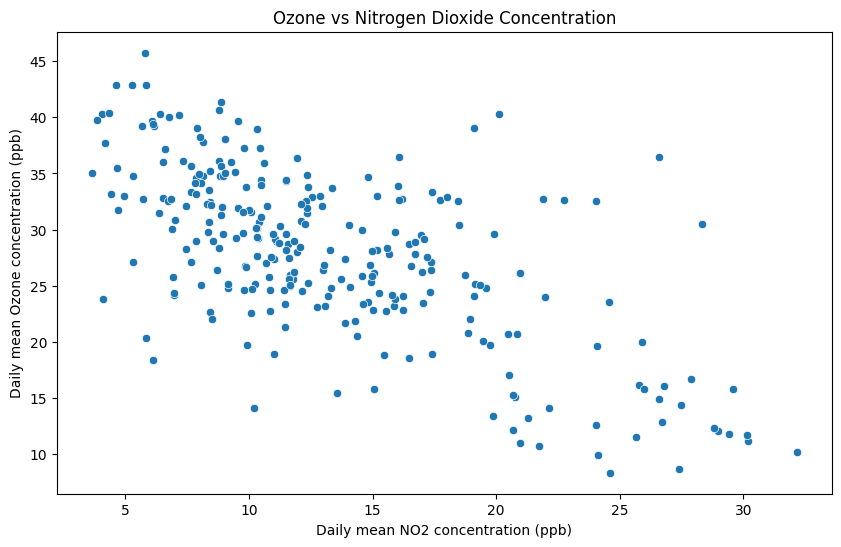

In [17]:
df_all = df_O3[["Date (Local)", "O3"]].merge(df_NO2[["Date (Local)", "NO2"]], on="Date (Local)").dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_all, x="NO2", y="O3")
plt.title("Ozone vs Nitrogen Dioxide Concentration")
plt.xlabel("Daily mean NO2 concentration (ppb)")
plt.ylabel("Daily mean Ozone concentration (ppb)")
plt.show()

In [31]:
xVal = df_all["NO2"].values.reshape(-1, 1)
yVal = df_all["O3"].values

X_train, X_test, y_train, y_test = train_test_split(xVal, yVal, test_size=0.2)

reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

print(reg.coef_)
print(reg.intercept_)

[-0.82173292]
39.02825206224205


In [33]:
df_test = pd.DataFrame({'x' : X_test.ravel(), 'y' : y_test.ravel()})
df_test['yPred'] = reg.predict(X_test)

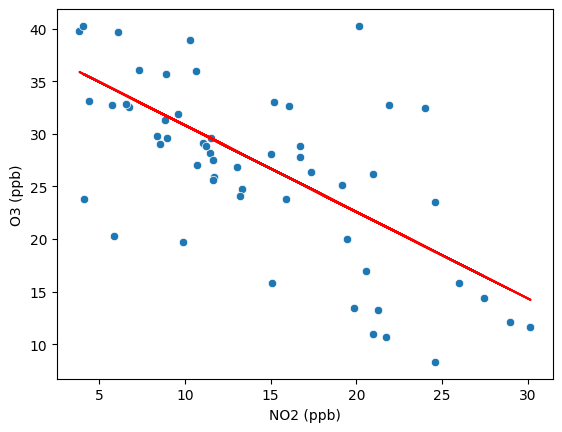

In [36]:
sns.scatterplot(data=df_test, x="x", y="y")
plt.plot(df_test['x'], df_test['yPred'], color='r')
plt.xlabel("NO2 (ppb)")
plt.ylabel("O3 (ppb)")
plt.show()

In [39]:
mse = mean_squared_error(y_test, df_test['yPred'])
print("Mean Squared Error:", mse, "ppb^2")

Mean Squared Error: 40.268003621621304 ppb^2


In [45]:
df_co2 = pd.read_csv("ManuaLoa_CO2.csv")

In [52]:
df_train = df_co2[df_co2["decimal date"] < 2000].copy()
df_test = df_co2[df_co2["decimal date"] >= 2000].copy()

X_train2 = df_train["decimal date"].values.reshape(-1, 1)
y_train2 = df_train["average"].values

X_test2 = df_test["decimal date"].values.reshape(-1, 1)
y_test2 = df_test["average"].values

In [53]:
reg2 = linear_model.LinearRegression()
reg2.fit(X_train2, y_train2)

print(reg2.coef_)
print(reg2.intercept_)

[1.32328923]
-2280.591072256732


In [61]:
df_test2 = pd.DataFrame({'x' : X_test2.ravel(), 'y' : y_test2.ravel()})
df_test2['yPred'] = reg2.predict(X_test2)

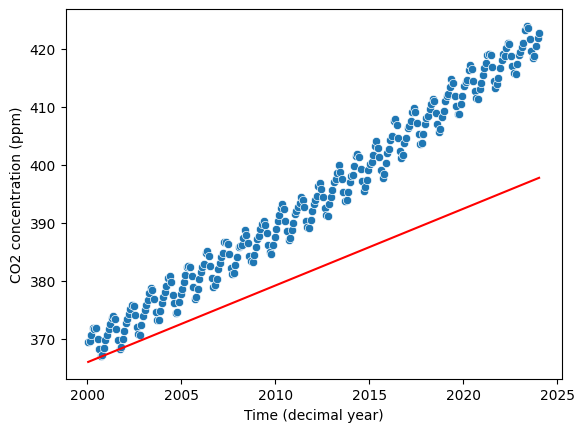

In [62]:
sns.scatterplot(data=df_test2, x="x", y="y")
plt.plot(df_test2['x'], df_test2['yPred'], color='r')
plt.xlabel("Time (decimal year)")
plt.ylabel("CO2 concentration (ppm)")
plt.show()

In [63]:
mse2 = mean_squared_error(y_test2, df_test2["yPred"])
print("Mean Squared Error:", mse2, "ppm^2")

Mean Squared Error: 200.2461711097249 ppm^2
